In [1]:
import numpy as np
import torch
import os
import numpy as np
import sigpy.mri as spmri
import sigpy as sp
import matplotlib.pyplot as plt

# --- Optional CuPy import + capability check ---
try:
    import cupy as cp
    _cupy_ok = True
    try:
        _gpu_count = cp.cuda.runtime.getDeviceCount()
        _cupy_ok = _gpu_count > 0
    except Exception:
        _cupy_ok = False
except Exception:
    cp = None
    _cupy_ok = False

from utils.show_slice import show_slice, show_kspace_slice, header_info
from utils.fftnc import fftnc, ifftnc # normalised fft and ifft for n dimensions
from utils.espiritmaps import calc_espirit_maps, to_espirit_dims, from_espirit_dims

# Set device for SigPy and PyTorch 
sp_device = sp.Device(0) if _cupy_ok else sp.Device(-1)
device = torch.device("cuda:0" if _cupy_ok and torch.cuda.is_available() else "cpu")

# This a a slice from fastMRI dataset saved as a numpy array to test this pipeline
kspace = np.load("data/kspace.npz")['arr_0']
kspace = torch.from_numpy(kspace).to(device)

nCha, nX, nY, nSlices = kspace.shape
image_shape = nX, nY, nSlices, nCha

/home/henri/miniforge3/envs/MRI/lib/python3.13/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
No module named 'cupyx.cudnn'
  warnings.warn(


Protocol: AX T1_FBB

Scanner: SIEMENS Skyra 2.8936 T

Coils: 20

Matrix: 640 x 320

FOV: 440 mm x 220 mm

TR: 250 ms

TE: 3.4 ms

### Changing Parameters

In [2]:
model = 0
solver = 1
iterations = 42
max_motion = 2.0  # maximum translation in pixels/rotation in degrees
seed = 42

max_motion = max_motion * 3/2  # ~~ in pixels

EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

/home/henri/miniforge3/envs/MRI/lib/python3.13/site-packages/sigpy/pytorch.py:39: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  tensor = from_dlpack(array.toDlpack())
/home/henri/miniforge3/envs/MRI/lib/python3.13/site-packages/torch/nn/functional.py:5116: UserWarning: Since version 1.3.0, affine_grid behavior has changed for unit-size grids when align_corners=True. This is not an intended use case of affine_grid. See the documentation of affine_grid for details.
  warnings.warn(


Allocated: 0.135856128 GB
Allocated: 0.077289472 GB


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

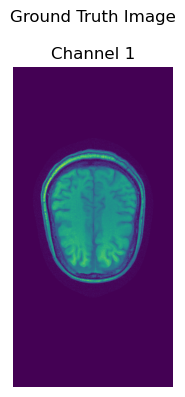

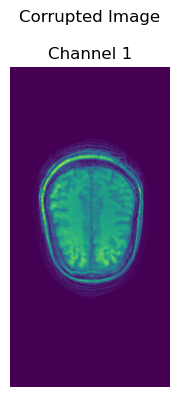

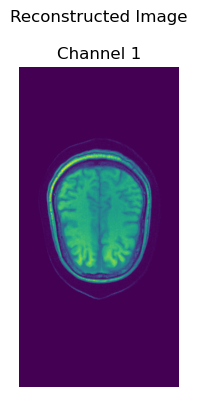

In [3]:
from utils.known_motion import solve_known_motion_artifacts

p_true, p_corrupted, x_rec = solve_known_motion_artifacts(
        kspace=kspace,
        model=model,
        solver=solver,
        iterations=iterations,
        sigma=max_motion,
        seed=seed,
        sp_device=sp_device
)
# Show results
show_slice(p_true, max_images=1, headline="Ground Truth Image")
show_slice(p_corrupted, max_images=1, headline="Corrupted Image")
show_slice(x_rec, max_images=1, headline="Reconstructed Image")